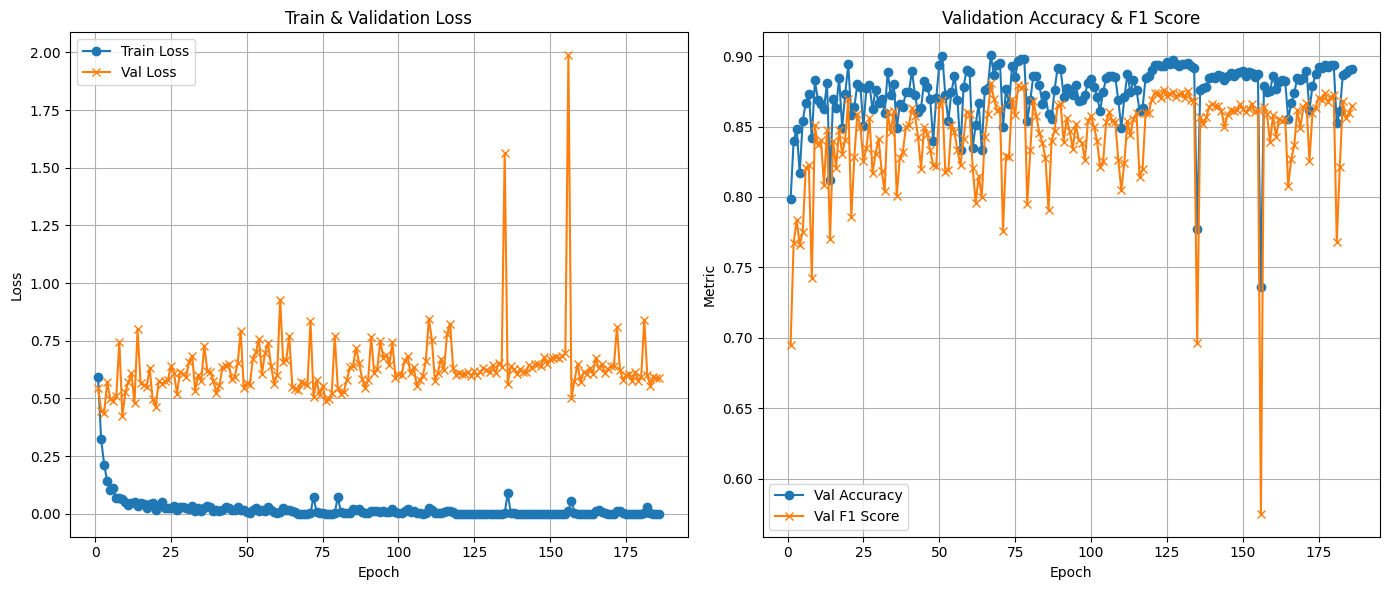

In [1]:
import re
import matplotlib.pyplot as plt

# 로그 파일 경로
log_path = '/nahcooy/OSR/classify/Resnet/log/train_resnet_0410_02.txt'

# 저장할 리스트
train_epochs = []
val_epochs = []
train_losses = []
val_losses = []
val_accuracies = []
val_f1s = []

with open(log_path, 'r', encoding='utf-8') as f:
    lines = f.readlines()
    for i in range(len(lines)):
        line = lines[i]

        # 🔹 Epoch 및 Train Loss
        if 'Avg Train Loss:' in line:
            epoch_match = re.search(r"Epoch (\d+)", line)
            train_loss_match = re.search(r"Avg Train Loss: ([\d.]+)", line)

            if epoch_match and train_loss_match:
                epoch = int(epoch_match.group(1))
                train_loss = float(train_loss_match.group(1))

                train_epochs.append(epoch)
                train_losses.append(train_loss)

        # 🔸 Validation 지표
        if 'Validation:' in line:
            val_line = lines[i + 1].strip()
            f1_line = lines[i + 2].strip()

            epoch_match = re.search(r"Epoch \[(\d+)", line)  # Epoch [N/XXX] 형태에서 추출
            if epoch_match:
                val_epoch = int(epoch_match.group(1))
                val_epochs.append(val_epoch)

            val_loss_match = re.search(r"Val Loss: ([\d.]+), Top-1 Acc: ([\d.]+)", val_line)
            f1_match = re.search(r"F1: ([\d.]+)", f1_line)

            if val_loss_match:
                val_losses.append(float(val_loss_match.group(1)))
                val_accuracies.append(float(val_loss_match.group(2)))
            else:
                val_losses.append(None)
                val_accuracies.append(None)

            if f1_match:
                val_f1s.append(float(f1_match.group(1)))
            else:
                val_f1s.append(None)

# 시각화
plt.figure(figsize=(14, 6))

# 🔹 Loss 그래프
plt.subplot(1, 2, 1)
plt.plot(train_epochs, train_losses, label='Train Loss', marker='o')
plt.plot(val_epochs, val_losses, label='Val Loss', marker='x')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Train & Validation Loss')
plt.legend()
plt.grid(True)

# 🔹 Accuracy & F1 Score 그래프
plt.subplot(1, 2, 2)
plt.plot(val_epochs, val_accuracies, label='Val Accuracy', marker='o')
plt.plot(val_epochs, val_f1s, label='Val F1 Score', marker='x')
plt.xlabel('Epoch')
plt.ylabel('Metric')
plt.title('Validation Accuracy & F1 Score')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()
